In [2]:
r"""
================================================================================
 ane_K_convergence.py
 Convergence of the ANE estimator in the bank size K, at a fixed SNR.
 Companion experiment for WWB_SR_v9.tex  (single tone, D = 1, N = 32).
================================================================================

WHAT THIS MEASURES
------------------
For K = 4, 6, 8, 10, ... this script trains a perturbation bank
Z = [z_1,...,z_K]^T in R^{K x N} with Algorithm 1 of the manuscript, and
evaluates the Bayesian MSE of

    theta_ANE(x; Z) = (1/K) sum_k theta_MAP(x + z_k)

on a *common* test set (same realizations for every K), together with the
MAP and MMSE references.

WHAT TO EXPECT  (please read before interpreting the curve)
-----------------------------------------------------------
Proposition 1(iii) of the manuscript says the optimal NE estimator is the
L^2 projection of theta_MMSE onto conv(A), where

    A = { theta_MAP( . + z) : ||z|| <= beta * sigma_v }.

As K -> infinity the K-point family becomes dense in conv(A), so

    lim_{K->inf} MSE_ANE(K) = MSE_min + dist^2( theta_MMSE , conv(A) )

which is >= MSE_min, with EQUALITY IF AND ONLY IF theta_MMSE lies in the
closed convex hull of the shifted MAP estimators. There is no reason for
that to hold. The expected outcome is therefore:

    ANE saturates at a floor STRICTLY ABOVE MMSE, and the residual gap is
    the projection distance -- not an optimization failure.

Two corollaries worth testing, both supported below:

  (a) The floor depends on beta, because beta sets the radius of Z and hence
      the size of conv(A). Use --beta-sweep to see whether the floor drops
      as beta grows. If the floor is insensitive to beta, the gap is
      structural; if it drops, the bank was radius-limited.

  (b) Proposition 3 predicts an O(1/K) risk penalty for a *random* K-atom
      bank. The script therefore also evaluates an untrained zero-sum random
      bank at each K, and fits

          MSE(K) ~= MSE_inf + c / K

      by least squares on x = 1/K, so that MSE_inf can be extrapolated and
      compared against MSE_MMSE with a standard error.

CONFOUND TO CONTROL
-------------------
As K grows the training problem has K*N parameters, so a rise in MSE(K) can
be optimization failure rather than theory. Three safeguards are built in:
  * common random numbers -- the SAME test set for every K, so the curve is
    paired and differences are far better resolved than absolute MSEs;
  * warm starting -- the K-bank is initialised (among other candidates) by
    tiling the previous, smaller bank, which is exact when K is a multiple
    of the previous K and near-exact otherwise;
  * multiple restarts, selected on an INDEPENDENT validation set.
Also watch the printed train/val gap: if it widens with K, raise --m-train.

theta-mode
----------
Default is --theta-mode prior, i.e. theta ~ U[0,pi], which is the Bayesian
risk the theory is about. --theta-mode fixed evaluates the CONDITIONAL MSE
at a single theta (Fig. 2's setting). Note that under `fixed`, theta_MMSE is
NOT a lower bound -- the posterior mean is pulled toward the prior mean, so
ANE can appear to beat MMSE at a favourable theta. Use `prior` for the
convergence question.

USAGE
-----
    python ane_K_convergence.py --quick                # ~1 min smoke test
    python ane_K_convergence.py                        # full run
    python ane_K_convergence.py --check-grad           # verify IFT gradient
    python ane_K_convergence.py --beta-sweep 2 4 8 16  # floor vs beta
    python ane_K_convergence.py --device cuda --dtype float32

Outputs: ane_K_convergence.json, ane_K_convergence.npz, and (if matplotlib
is present) ane_K_convergence.png.

NOTE: this script has NOT been executed. Run --check-grad and --quick first.
================================================================================
"""

import argparse
import json
import math
import time
from dataclasses import dataclass, field, asdict

import numpy as np
import torch


# ==============================================================================
#  Configuration
# ==============================================================================
@dataclass
class Config:
    # ---- signal model ----
    N: int = 32                      # number of samples
    A: float = 1.0                   # tone amplitude
    snr_db: float = -3.0             # per-tone SNR, gamma = A^2 / (2 sigma_v^2)
    theta_lo: float = 0.0
    theta_hi: float = math.pi

    # ---- MAP estimator ----
    n_grid: int = 1024               # N_theta, coarse dictionary grid
    newton_iters: int = 3            # T
    step_cap_cells: float = 4.0      # Newton step capped at this many grid cells

    # ---- MMSE reference ----
    n_quad: int = 4096               # N_q, posterior quadrature grid

    # ---- perturbation bank ----
    beta: float = 4.0                # ||z_k|| <= beta * sigma_v
    K_list: tuple = (4, 6, 8, 10, 12, 16, 20, 24, 32, 48, 64)

    # ---- data set sizes ----
    m_train: int = 8000
    m_val: int = 8000
    m_test: int = 100000
    m_mcne: int = 2000               # MC-NE is evaluated on a subset (expensive)
    l_mc: int = 4000                 # L for the Monte-Carlo NE reference

    # ---- Algorithm 1 ----
    n_restarts: int = 3
    max_iters: int = 120             # T_r
    eta0: float = 0.5
    eta_min: float = 1e-4
    eta_up: float = 1.3
    alphas: tuple = (0.1, 0.5, 1.0, 2.0, 3.0, 4.0)
    z_sig: float = 3.0               # significance level of the activation gate
    kappa: float = 0.02              # minimum relative MSE gain
    # Delta (anomaly threshold) is set to the mainlobe width 2*pi/N.

    # ---- evaluation protocol ----
    theta_mode: str = "prior"        # {"prior", "fixed"}
    theta_fixed: float = 0.4 * math.pi

    # ---- runtime ----
    chunk: int = 4096                # samples per evaluation chunk
    seed: int = 0
    device: str = "cpu"
    dtype: str = "float32"

    @property
    def sigma_v(self) -> float:
        gamma = 10.0 ** (self.snr_db / 10.0)
        return math.sqrt(self.A ** 2 / (2.0 * gamma))


# ==============================================================================
#  Signal model: MAP, MMSE and ANE estimators
# ==============================================================================
class ToneModel:
    """Single tone x(n) = A cos(n*theta) + v(n), v ~ N(0, sigma_v^2 I)."""

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.dev = torch.device(cfg.device)
        self.dt = dict(float32=torch.float32, float64=torch.float64)[cfg.dtype]
        self.sigma_v = cfg.sigma_v

        self.n = torch.arange(1, cfg.N + 1, device=self.dev, dtype=self.dt)

        # ---- coarse dictionary for the MAP grid stage --------------------
        # midpoint rule on (theta_lo, theta_hi)
        j = torch.arange(cfg.n_grid, device=self.dev, dtype=self.dt)
        self.dphi = (cfg.theta_hi - cfg.theta_lo) / cfg.n_grid
        self.phi = cfg.theta_lo + (j + 0.5) * self.dphi          # (n_grid,)
        self.S = cfg.A * torch.cos(self.n[:, None] * self.phi[None, :])   # (N, n_grid)
        self.half_norm2 = 0.5 * (self.S ** 2).sum(0)             # (n_grid,)

        # ---- dense quadrature grid for the MMSE reference ----------------
        jq = torch.arange(cfg.n_quad, device=self.dev, dtype=self.dt)
        dq = (cfg.theta_hi - cfg.theta_lo) / cfg.n_quad
        self.phi_q = cfg.theta_lo + (jq + 0.5) * dq              # (n_quad,)
        self.S_q = cfg.A * torch.cos(self.n[:, None] * self.phi_q[None, :])
        self.half_norm2_q = 0.5 * (self.S_q ** 2).sum(0)

        self.step_cap = cfg.step_cap_cells * self.dphi
        self.eps_H = 1e-9

    # ---------------------------------------------------------------- data
    def simulate(self, m: int, gen: torch.Generator):
        """Draw (theta, x). theta from the prior, or held fixed."""
        cfg = self.cfg
        if cfg.theta_mode == "prior":
            u = torch.rand(m, generator=gen, device=self.dev, dtype=self.dt)
            theta = cfg.theta_lo + u * (cfg.theta_hi - cfg.theta_lo)
        elif cfg.theta_mode == "fixed":
            theta = torch.full((m,), cfg.theta_fixed, device=self.dev, dtype=self.dt)
        else:
            raise ValueError(f"unknown theta_mode {cfg.theta_mode!r}")

        s = cfg.A * torch.cos(theta[:, None] * self.n[None, :])           # (m, N)
        v = torch.randn(m, cfg.N, generator=gen, device=self.dev, dtype=self.dt)
        return theta, s + self.sigma_v * v

    def corr(self, X):
        """Shared data correlation X @ S -- Eq. (33), computed once per data set."""
        return X @ self.S                                                 # (m, n_grid)

    # ------------------------------------------------------- MAP estimator
    def _derivs(self, theta, Xp):
        """s, ds/dtheta, d2s/dtheta2 and the residual at theta."""
        arg = theta[:, None] * self.n[None, :]                            # (m, N)
        c, s_ = torch.cos(arg), torch.sin(arg)
        sig = self.cfg.A * c
        ds = -self.cfg.A * self.n[None, :] * s_
        d2s = -self.cfg.A * (self.n[None, :] ** 2) * c
        return sig, ds, d2s, (Xp - sig)

    def _gH(self, ds, d2s, r):
        """Gradient and Hessian of J(theta) = 0.5*||x - s(theta)||^2.

        Safeguard: fall back to the Gauss-Newton Hessian ds^T ds whenever the
        full Hessian is not comfortably positive, which happens off the peak.
        """
        g = -(ds * r).sum(-1)                                             # (m,)
        H_gn = (ds * ds).sum(-1)
        H = H_gn - (r * d2s).sum(-1)
        H = torch.where(H > 1e-3 * H_gn, H, H_gn)
        return g, H.clamp_min(self.eps_H)

    def _newton(self, theta0, Xp, need_grad=False):
        """T Newton steps from the grid initialisation, then optionally the
        implicit-function-theorem gradient  d(theta_hat)/dx = J / H  (Eq. 29)."""
        th = theta0
        for _ in range(self.cfg.newton_iters):
            _, ds, d2s, r = self._derivs(th, Xp)
            g, H = self._gH(ds, d2s, r)
            step = (g / H).clamp(-self.step_cap, self.step_cap)
            th = (th - step).clamp(self.cfg.theta_lo, self.cfg.theta_hi)

        if not need_grad:
            return th, None

        _, ds, d2s, r = self._derivs(th, Xp)
        _, H = self._gH(ds, d2s, r)
        return th, ds / H[:, None]                                        # (m, N)

    def map_estimate(self, X, XS=None, z=None, need_grad=False):
        """MAP estimate of x + z. XS = X @ S may be passed in and reused."""
        if XS is None:
            XS = self.corr(X)
        scores = XS - self.half_norm2[None, :]
        if z is not None:
            scores = scores + (z @ self.S)[None, :]                       # Eq. (33)
        th0 = self.phi[scores.argmax(-1)]
        Xp = X if z is None else X + z[None, :]
        return self._newton(th0, Xp, need_grad=need_grad)

    # ------------------------------------------------------ MMSE estimator
    def mmse_estimate(self, X):
        """Posterior mean under the uniform prior, by dense quadrature."""
        logw = (X @ self.S_q - self.half_norm2_q[None, :]) / (self.sigma_v ** 2)
        w = torch.softmax(logw, dim=-1)                                   # stable
        return w @ self.phi_q

    # ------------------------------------------------------- ANE estimator
    def ane_apply(self, X, XS, Z, need_grad=False):
        """theta_ANE = (1/K) sum_k theta_MAP(x + z_k).  Returns per-branch
        IFT gradients when need_grad, as a list of K tensors of shape (m, N)."""
        K = Z.shape[0]
        Gamma = Z @ self.S                                                # (K, n_grid)
        base = XS - self.half_norm2[None, :]
        th_sum = torch.zeros(X.shape[0], device=self.dev, dtype=self.dt)
        grads = [] if need_grad else None
        for k in range(K):
            th0 = self.phi[(base + Gamma[k][None, :]).argmax(-1)]
            th_k, g_k = self._newton(th0, X + Z[k][None, :], need_grad=need_grad)
            th_sum = th_sum + th_k
            if need_grad:
                grads.append(g_k)
        return th_sum / K, grads


# ==============================================================================
#  Feasible set: exact retraction onto  Omega = S (zero-sum) cap B (norm ball)
#  Proposition 5. A single POCS sweep P_B o P_S is NOT feasible, because
#  row-wise clipping destroys the zero-sum property; a COMMON scaling is.
# ==============================================================================
def retract(Z, radius):
    Zs = Z - Z.mean(dim=0, keepdim=True)                 # P_S
    rmax = Zs.norm(dim=1).max()
    c = torch.clamp(radius / (rmax + 1e-30), max=1.0)    # common scale
    return c * Zs


def random_bank(K, N, radius, gen, device, dtype, alpha=1.0):
    """Centred, row-normalised Gaussian bank, scaled and retracted."""
    U = torch.randn(K, N, generator=gen, device=device, dtype=dtype)
    U = U - U.mean(dim=0, keepdim=True)
    U = U / U.norm(dim=1, keepdim=True).clamp_min(1e-30)
    return retract(alpha * radius * U, radius)


# ==============================================================================
#  Empirical risk and its analytic gradient  (Eqs. 30-31)
# ==============================================================================
def loss_and_grad(model, X, XS, theta, Z, need_grad=True):
    m, K = X.shape[0], Z.shape[0]
    th_ane, grads = model.ane_apply(X, XS, Z, need_grad=need_grad)
    resid = th_ane - theta
    loss = (resid.double() ** 2).mean().item()
    if not need_grad:
        return loss, None
    G = torch.stack([(2.0 / (m * K)) * (grads[k] * resid[:, None]).sum(0)
                     for k in range(K)])                                  # (K, N)
    return loss, G


def loss_only(model, X, XS, theta, Z):
    return loss_and_grad(model, X, XS, theta, Z, need_grad=False)[0]


# ==============================================================================
#  Algorithm 1, stages 1-3
# ==============================================================================
def train_bank(model, cfg, K, Xtr, XStr, thtr, gen, warm_start=None, verbose=False):
    """Stage 1 (multi-scale + warm-start initialisation) and stage 2 (monotone
    backtracking projected gradient). Returns (Z, train_loss, history)."""
    radius = cfg.beta * model.sigma_v
    N = cfg.N

    # ---- stage 1: candidate set C, always containing the zero bank -------
    cands = [torch.zeros(K, N, device=model.dev, dtype=model.dt)]
    U = torch.randn(K, N, generator=gen, device=model.dev, dtype=model.dt)
    U = U - U.mean(dim=0, keepdim=True)
    U = U / U.norm(dim=1, keepdim=True).clamp_min(1e-30)
    for a in cfg.alphas:
        cands.append(retract(a * model.sigma_v * U, radius))
    if warm_start is not None:
        # tile the previous (smaller) bank up to K rows; exact when K is a
        # multiple of the previous size, near-exact otherwise
        Kp = warm_start.shape[0]
        idx = torch.arange(K, device=model.dev) % Kp
        cands.append(retract(warm_start[idx].clone(), radius))

    losses = [loss_only(model, Xtr, XStr, thtr, Z) for Z in cands]
    b = int(np.argmin(losses))
    Z, L = cands[b].clone(), losses[b]
    if verbose:
        print(f"      init: best of {len(cands)} candidates (idx {b}), L = {L:.6f}")

    # ---- stage 2: monotone projected gradient ----------------------------
    eta, hist = cfg.eta0, [L]
    for _ in range(cfg.max_iters):
        _, G = loss_and_grad(model, Xtr, XStr, thtr, Z, need_grad=True)
        gmax = G.abs().max().clamp_min(1e-30)
        accepted = False
        while True:
            Zt = retract(Z - (eta / gmax) * G, radius)
            Lt = loss_only(model, Xtr, XStr, thtr, Zt)
            if Lt < L:
                Z, L, accepted = Zt, Lt, True
                eta *= cfg.eta_up
                break
            eta *= 0.5
            if eta < cfg.eta_min:
                break
        hist.append(L)
        if not accepted:
            break
    return Z, L, hist


def activation_gate(model, cfg, Z, Xv, XSv, thv):
    """Stage 3. Paired t-statistic, McNemar statistic and relative MSE gain."""
    th_ane, _ = model.ane_apply(Xv, XSv, Z, need_grad=False)
    th_map, _ = model.map_estimate(Xv, XS=XSv)
    e = (th_ane - thv).abs().double()
    e0 = (th_map - thv).abs().double()

    d = e ** 2 - e0 ** 2
    Mv = d.numel()
    sd = d.std(unbiased=True).clamp_min(1e-30)
    T_t = (d.mean() * math.sqrt(Mv) / sd).item()

    Delta = 2.0 * math.pi / cfg.N                          # mainlobe width
    n10 = int(((e0 > Delta) & (e <= Delta)).sum())
    n01 = int(((e0 <= Delta) & (e > Delta)).sum())
    T_mc = (n10 - n01) / math.sqrt(max(n10 + n01, 1))

    g = 1.0 - (e ** 2).sum().item() / max((e0 ** 2).sum().item(), 1e-30)
    passed = ((T_t < -cfg.z_sig) or (T_mc > cfg.z_sig)) and (g >= cfg.kappa)
    return passed, dict(T_t=T_t, T_mc=T_mc, n10=n10, n01=n01, gain=g)


# ==============================================================================
#  Chunked evaluation on the (large, common) test set
# ==============================================================================
def eval_squared_errors(model, cfg, Xte, thte, kind, Z=None, gen=None, L=None):
    """Per-sample squared errors, so that PAIRED comparisons across K are
    available afterwards. kind in {'map', 'mmse', 'ane', 'mcne'}."""
    out = torch.empty(Xte.shape[0], dtype=torch.float64)
    for i in range(0, Xte.shape[0], cfg.chunk):
        Xc = Xte[i:i + cfg.chunk]
        thc = thte[i:i + cfg.chunk]
        if kind == "mmse":
            est = model.mmse_estimate(Xc)
        else:
            XSc = model.corr(Xc)
            if kind == "map":
                est, _ = model.map_estimate(Xc, XS=XSc)
            elif kind == "ane":
                est, _ = model.ane_apply(Xc, XSc, Z, need_grad=False)
            elif kind == "mcne":
                Zr = torch.randn(L, cfg.N, generator=gen,
                                 device=model.dev, dtype=model.dt) * model.sigma_v
                est, _ = model.ane_apply(Xc, XSc, Zr, need_grad=False)
            else:
                raise ValueError(kind)
        out[i:i + cfg.chunk] = ((est - thc) ** 2).double().cpu()
    return out


def mse_with_se(sq):
    """MSE and its standard error (the squared error is heavy-tailed, so the
    SE matters: the outlier population dominates the variance)."""
    return sq.mean().item(), (sq.std(unbiased=True) / math.sqrt(sq.numel())).item()


def paired_diff(sq_a, sq_b):
    """Paired mean difference a - b and its SE. Common random numbers make
    this far tighter than differencing two independent MSE estimates."""
    d = sq_a - sq_b
    return d.mean().item(), (d.std(unbiased=True) / math.sqrt(d.numel())).item()


# ==============================================================================
#  Extrapolation:  MSE(K) ~= MSE_inf + c/K
# ==============================================================================
def fit_inverse_K(Ks, mses, ses=None, k_min=8):
    """Weighted least squares of MSE on 1/K, restricted to K >= k_min.
    Returns MSE_inf, c and the standard error of MSE_inf."""
    Ks, mses = np.asarray(Ks, float), np.asarray(mses, float)
    sel = Ks >= k_min
    if sel.sum() < 3:
        return None
    x, y = 1.0 / Ks[sel], mses[sel]
    w = np.ones_like(y) if ses is None else 1.0 / np.maximum(np.asarray(ses, float)[sel], 1e-12) ** 2
    Amat = np.stack([np.ones_like(x), x], axis=1)
    W = np.diag(w)
    cov = np.linalg.inv(Amat.T @ W @ Amat)
    beta = cov @ (Amat.T @ W @ y)
    resid = y - Amat @ beta
    dof = max(len(y) - 2, 1)
    s2 = float(resid @ (W @ resid)) / dof                 # scale the covariance
    return dict(mse_inf=float(beta[0]), c=float(beta[1]),
                se_mse_inf=float(math.sqrt(max(cov[0, 0] * s2, 0.0))),
                n_points=int(sel.sum()))


# ==============================================================================
#  Gradient check (run this first -- the IFT gradient is the one thing here
#  that is easy to get wrong, and autograd cannot validate it because the
#  grid argmax is piecewise constant)
# ==============================================================================
def check_gradient(model, cfg, seed=1234, K=4, m=256, eps=1e-4):
    print("\n[gradient check] analytic IFT gradient vs central differences")
    print("  NOTE: L(Z) is piecewise smooth -- the grid peak of a branch can")
    print("  flip under the perturbation, so a few entries may disagree. Look")
    print("  at the MEDIAN relative error, not the max. float64 recommended.")
    gen = torch.Generator(device=model.dev).manual_seed(seed)
    th, X = model.simulate(m, gen)
    XS = model.corr(X)
    Z = random_bank(K, cfg.N, cfg.beta * model.sigma_v, gen,
                    model.dev, model.dt, alpha=1.0)

    _, G = loss_and_grad(model, X, XS, th, Z, need_grad=True)

    rel, idxs = [], [(k, j) for k in range(K) for j in range(0, cfg.N, 7)]
    for (k, j) in idxs:
        Zp, Zm = Z.clone(), Z.clone()
        Zp[k, j] += eps
        Zm[k, j] -= eps
        # NOTE: no retraction here -- we are differentiating L, not the
        # projected map, so the finite difference must stay off-manifold.
        num = (loss_only(model, X, XS, th, Zp) - loss_only(model, X, XS, th, Zm)) / (2 * eps)
        ana = G[k, j].item()
        rel.append(abs(num - ana) / max(abs(num), abs(ana), 1e-12))
    rel = np.asarray(rel)
    print(f"  entries checked : {len(rel)}")
    print(f"  median rel err  : {np.median(rel):.3e}")
    print(f"  90th pct        : {np.percentile(rel, 90):.3e}")
    print(f"  max             : {rel.max():.3e}")
    ok = np.median(rel) < 5e-2
    print(f"  VERDICT         : {'PASS' if ok else 'FAIL -- inspect _newton/_gH'}")
    return ok


# ==============================================================================
#  Main sweep
# ==============================================================================
def run_sweep(cfg: Config, verbose=True):
    torch.manual_seed(cfg.seed)
    model = ToneModel(cfg)
    dev, dt = model.dev, model.dt
    radius = cfg.beta * model.sigma_v

    print("=" * 78)
    print(f" ANE convergence in K   |  N={cfg.N}  SNR={cfg.snr_db} dB  "
          f"sigma_v={model.sigma_v:.4f}  beta={cfg.beta}")
    print(f" theta_mode={cfg.theta_mode}  device={cfg.device}  dtype={cfg.dtype}")
    print("=" * 78)

    # ---- data sets. The TEST set is generated once and shared by every K --
    g_tr = torch.Generator(device=dev).manual_seed(cfg.seed + 1)
    g_va = torch.Generator(device=dev).manual_seed(cfg.seed + 2)
    g_te = torch.Generator(device=dev).manual_seed(cfg.seed + 3)
    g_rb = torch.Generator(device=dev).manual_seed(cfg.seed + 4)

    th_tr, X_tr = model.simulate(cfg.m_train, g_tr)
    th_va, X_va = model.simulate(cfg.m_val, g_va)
    th_te, X_te = model.simulate(cfg.m_test, g_te)
    XS_tr, XS_va = model.corr(X_tr), model.corr(X_va)

    # ---- K-independent references ---------------------------------------
    t0 = time.time()
    sq_map = eval_squared_errors(model, cfg, X_te, th_te, "map")
    sq_mmse = eval_squared_errors(model, cfg, X_te, th_te, "mmse")
    mse_map, se_map = mse_with_se(sq_map)
    mse_mmse, se_mmse = mse_with_se(sq_mmse)
    prior_var = (cfg.theta_hi - cfg.theta_lo) ** 2 / 12.0

    print(f"\n  MAP   : {mse_map:.6f}  +/- {se_map:.6f}")
    print(f"  MMSE  : {mse_mmse:.6f}  +/- {se_mmse:.6f}")
    print(f"  prior variance (pi^2/12) : {prior_var:.6f}")
    print(f"  MAP-to-MMSE gap          : {mse_map - mse_mmse:.6f}")
    print(f"  [references took {time.time()-t0:.1f} s]")

    # ---- Monte-Carlo NE reference on a subset ----------------------------
    mse_mcne = se_mcne = None
    if cfg.l_mc > 0 and cfg.m_mcne > 0:
        t0 = time.time()
        sq_mc = eval_squared_errors(model, cfg, X_te[:cfg.m_mcne], th_te[:cfg.m_mcne],
                                    "mcne", gen=g_rb, L=cfg.l_mc)
        mse_mcne, se_mcne = mse_with_se(sq_mc)
        print(f"  MC-NE (L={cfg.l_mc}, {cfg.m_mcne} samples): "
              f"{mse_mcne:.6f} +/- {se_mcne:.6f}   [{time.time()-t0:.1f} s]")

    # ---- sweep over K ----------------------------------------------------
    rows, sq_by_K, warm = [], {}, None
    print("\n" + "-" * 78)
    for K in cfg.K_list:
        t0 = time.time()
        best = None
        for r in range(cfg.n_restarts):
            g_r = torch.Generator(device=dev).manual_seed(1000 * cfg.seed + 97 * K + r)
            Z, Ltr, hist = train_bank(model, cfg, K, X_tr, XS_tr, th_tr, g_r,
                                      warm_start=warm if r == 0 else None,
                                      verbose=False)
            Lva = loss_only(model, X_va, XS_va, th_va, Z)     # select on validation
            if best is None or Lva < best[2]:
                best = (Z, Ltr, Lva, len(hist))
        Z, Ltr, Lva, n_it = best

        passed, gate = activation_gate(model, cfg, Z, X_va, XS_va, th_va)
        Z_dep = Z if passed else torch.zeros_like(Z)          # deployed bank

        sq_ane = eval_squared_errors(model, cfg, X_te, th_te, "ane", Z=Z_dep)
        mse_ane, se_ane = mse_with_se(sq_ane)
        d_mmse, sd_mmse = paired_diff(sq_ane, sq_mmse)        # paired: much tighter
        d_map, sd_map = paired_diff(sq_ane, sq_map)

        # untrained zero-sum random bank of the same size (tests Prop. 3's 1/K)
        Zr = random_bank(K, cfg.N, radius, g_rb, dev, dt, alpha=1.0)
        sq_rnd = eval_squared_errors(model, cfg, X_te, th_te, "ane", Z=Zr)
        mse_rnd, _ = mse_with_se(sq_rnd)

        rows.append(dict(K=K, mse_ane=mse_ane, se_ane=se_ane,
                         mse_random_bank=mse_rnd,
                         train_loss=Ltr, val_loss=Lva, iters=n_it,
                         gate_passed=bool(passed), **gate,
                         d_vs_mmse=d_mmse, se_d_vs_mmse=sd_mmse,
                         d_vs_map=d_map, se_d_vs_map=sd_map,
                         radius_used=float(Z.norm(dim=1).max() / model.sigma_v),
                         seconds=time.time() - t0))
        sq_by_K[K] = sq_ane.numpy()
        warm = Z                                              # warm-start next K

        if verbose:
            print(f"  K={K:3d} | ANE {mse_ane:.6f} | rnd {mse_rnd:.6f} | "
                  f"train {Ltr:.6f} val {Lva:.6f} | gate {'Y' if passed else 'N'} "
                  f"(g={gate['gain']:+.3f}) | ANE-MMSE {d_mmse:+.6f}+/-{sd_mmse:.6f} "
                  f"| {time.time()-t0:.0f}s")

    # ---- extrapolate the floor ------------------------------------------
    Ks = [r["K"] for r in rows]
    ms = [r["mse_ane"] for r in rows]
    ss = [r["se_ane"] for r in rows]
    fit = fit_inverse_K(Ks, ms, ss, k_min=8)

    print("-" * 78)
    print("\nSUMMARY")
    print(f"  MSE_MAP                    = {mse_map:.6f}")
    print(f"  MSE_MMSE                   = {mse_mmse:.6f}")
    print(f"  MSE_ANE(K={Ks[-1]})              = {ms[-1]:.6f}")
    if fit:
        gap = fit["mse_inf"] - mse_mmse
        se_gap = math.sqrt(fit["se_mse_inf"] ** 2 + se_mmse ** 2)
        frac = (mse_map - fit["mse_inf"]) / max(mse_map - mse_mmse, 1e-12)
        print(f"  extrapolated MSE_inf       = {fit['mse_inf']:.6f} "
              f"+/- {fit['se_mse_inf']:.6f}   (fit on {fit['n_points']} points, "
              f"c = {fit['c']:.4f})")
        print(f"  projection gap to MMSE     = {gap:+.6f} +/- {se_gap:.6f}")
        print(f"  fraction of MAP-MMSE gap recovered = {100*frac:.1f} %")
        if gap > 3 * se_gap:
            print("  => ANE saturates STRICTLY ABOVE MMSE. This is the projection")
            print("     residual dist^2(theta_MMSE, conv(A)) of Proposition 1(iii),")
            print("     not an optimization failure. Try --beta-sweep to see")
            print("     whether enlarging the feasible radius lowers the floor.")
        else:
            print("  => the floor is statistically indistinguishable from MMSE.")

    res = dict(config=asdict(cfg), sigma_v=model.sigma_v,
               mse_map=mse_map, se_map=se_map,
               mse_mmse=mse_mmse, se_mmse=se_mmse,
               mse_mcne=mse_mcne, se_mcne=se_mcne,
               prior_var=prior_var, rows=rows, fit=fit)
    return res, sq_by_K, sq_map.numpy(), sq_mmse.numpy()


def beta_sweep(cfg: Config, betas):
    """Is the floor set by the radius, or is it structural?"""
    print("\n" + "=" * 78)
    print(" BETA SWEEP: floor vs perturbation radius")
    print("=" * 78)
    out = []
    for b in betas:
        c = Config(**{**asdict(cfg), "beta": float(b),
                      "K_list": tuple(k for k in cfg.K_list if k >= 8)})
        r, _, _, _ = run_sweep(c, verbose=False)
        floor = r["fit"]["mse_inf"] if r["fit"] else r["rows"][-1]["mse_ane"]
        out.append(dict(beta=float(b), mse_inf=floor,
                        gap=floor - r["mse_mmse"]))
        print(f"  beta={b:5.1f}  MSE_inf={floor:.6f}  gap to MMSE={floor - r['mse_mmse']:+.6f}")
    return out

ANE K-convergence experiment
SNR       = -7.0 dB
beta      = 4.0
K_list    = (2, 4, 6, 8, 10, 12, 16, 20, 24, 32)
m_train   = 8000
m_val     = 8000
m_test    = 100000
restarts  = 3
max_iters = 120
device    = cuda
dtype     = float32
 ANE convergence in K   |  N=32  SNR=-7.0 dB  sigma_v=1.5830  beta=4.0
 theta_mode=prior  device=cuda  dtype=float32

  MAP   : 0.573261  +/- 0.004348
  MMSE  : 0.390515  +/- 0.002396
  prior variance (pi^2/12) : 0.822467
  MAP-to-MMSE gap          : 0.182746
  [references took 0.4 s]
  MC-NE (L=4000, 2000 samples): 0.430377 +/- 0.013498   [4.9 s]

------------------------------------------------------------------------------
  K=  2 | ANE 0.486751 | rnd 0.533005 | train 0.484455 val 0.501328 | gate Y (g=+0.153) | ANE-MMSE +0.096237+/-0.001804 | 1s
  K=  4 | ANE 0.446605 | rnd 0.507931 | train 0.442725 val 0.459324 | gate Y (g=+0.224) | ANE-MMSE +0.056090+/-0.001275 | 1s
  K=  6 | ANE 0.431443 | rnd 0.440250 | train 0.426136 val 0.432340 | gate Y (g=+0.270

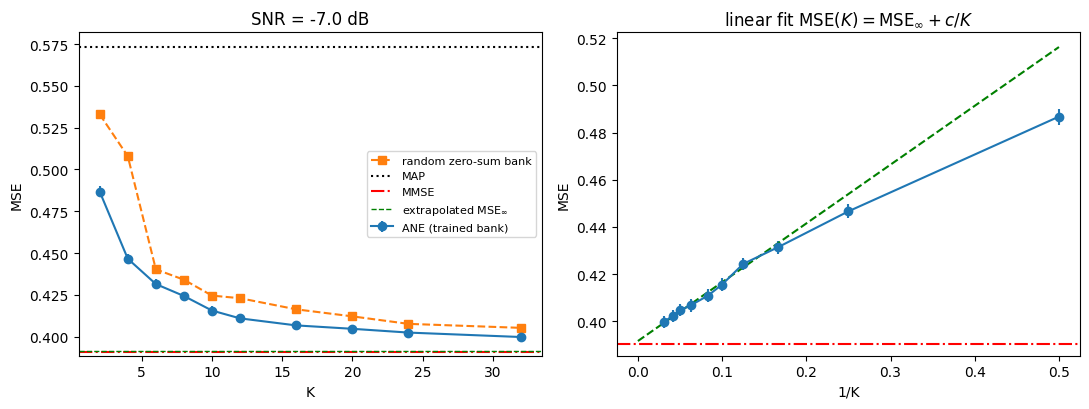

[plot written to ane_K_convergence.png]


In [5]:
# -----------------------------
# Basic parameters
# -----------------------------
snr_db = -7.0
beta = 4.0
# K values to test
K_list = (2, 4, 6, 8, 10, 12, 16, 20, 24, 32)
m_train = 8000
m_val = 8000
m_test = 100000
n_restarts = 3
max_iters = 120
theta_mode = "prior"       # "prior" or "fixed"
seed = 0

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = "float32"          # "float32" or "float64"

chunk = 4096

# Gradient checking
check_grad = False

# Optional beta sweep
beta_sweep_values = None
# Example:
# beta_sweep_values = [1.0, 2.0, 4.0, 8.0]

# Quick test mode
quick = False

# Output prefix
out = "ane_K_convergence"


# ==============================================================================
# Cell — Build configuration
# ==============================================================================

cfg = Config(
    snr_db=snr_db,
    beta=beta,
    m_train=m_train,
    m_val=m_val,
    m_test=m_test,
    n_restarts=n_restarts,
    max_iters=max_iters,
    theta_mode=theta_mode,
    seed=seed,
    device=device,
    dtype=dtype,
    chunk=chunk,
)

cfg.K_list = tuple(K_list)


# ==============================================================================
# Cell — Optional quick test
# ==============================================================================

if quick:
    cfg.K_list = (4, 8, 16)

    cfg.m_train = 1500
    cfg.m_val = 1500
    cfg.m_test = 20000

    cfg.n_restarts = 1
    cfg.max_iters = 25

    cfg.m_mcne = 300
    cfg.l_mc = 500


print("============================================================")
print("ANE K-convergence experiment")
print("============================================================")
print(f"SNR       = {cfg.snr_db} dB")
print(f"beta      = {cfg.beta}")
print(f"K_list    = {cfg.K_list}")
print(f"m_train   = {cfg.m_train}")
print(f"m_val     = {cfg.m_val}")
print(f"m_test    = {cfg.m_test}")
print(f"restarts  = {cfg.n_restarts}")
print(f"max_iters = {cfg.max_iters}")
print(f"device    = {cfg.device}")
print(f"dtype     = {cfg.dtype}")
print("============================================================")


# ==============================================================================
# Cell — Gradient check
# ==============================================================================

if check_grad:
    cfg64 = Config(
        **{
            **asdict(cfg),
            "dtype": "float64"
        }
    )

    check_gradient(
        ToneModel(cfg64),
        cfg64
    )


# ==============================================================================
# Cell — Run K sweep
# ==============================================================================

res, sq_by_K, sq_map, sq_mmse = run_sweep(cfg)


# ==============================================================================
# Cell — Optional beta sweep
# ==============================================================================

if beta_sweep_values is not None:
    res["beta_sweep"] = beta_sweep(
        cfg,
        beta_sweep_values
    )


# ==============================================================================
# Cell — Save numerical results
# ==============================================================================

json_path = f"{out}.json"
npz_path = f"{out}.npz"

with open(json_path, "w") as f:
    json.dump(
        res,
        f,
        indent=2
    )

np.savez_compressed(
    npz_path,
    sq_map=sq_map,
    sq_mmse=sq_mmse,
    **{
        f"sq_ane_K{k}": v
        for k, v in sq_by_K.items()
    }
)

print()
print(f"[written {json_path}]")
print(f"[written {npz_path}]")


# ==============================================================================
# Cell — Collect results for plotting
# ==============================================================================

Ks = [r["K"] for r in res["rows"]]

mse_ane = [
    r["mse_ane"]
    for r in res["rows"]
]

se_ane = [
    r["se_ane"]
    for r in res["rows"]
]

mse_random_bank = [
    r["mse_random_bank"]
    for r in res["rows"]
]

mse_map = res["mse_map"]
mse_mmse = res["mse_mmse"]


# ==============================================================================
# Cell — Plot
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(
    1,
    2,
    figsize=(11, 4.2)
)


# ------------------------------------------------------------------------------
# Left: MSE versus K
# ------------------------------------------------------------------------------

ax[0].errorbar(
    Ks,
    mse_ane,
    yerr=se_ane,
    marker="o",
    label="ANE (trained bank)"
)

ax[0].plot(
    Ks,
    mse_random_bank,
    marker="s",
    ls="--",
    label="random zero-sum bank"
)

ax[0].axhline(
    mse_map,
    color="k",
    ls=":",
    label="MAP"
)

ax[0].axhline(
    mse_mmse,
    color="r",
    ls="-.",
    label="MMSE"
)

if res["fit"]:
    ax[0].axhline(
        res["fit"]["mse_inf"],
        color="g",
        ls="--",
        lw=1,
        label=r"extrapolated $\mathrm{MSE}_\infty$"
    )

ax[0].set_xlabel("K")
ax[0].set_ylabel("MSE")

ax[0].legend(fontsize=8)

ax[0].set_title(
    f"SNR = {res['config']['snr_db']} dB"
)


# ------------------------------------------------------------------------------
# Right: MSE versus 1/K
# ------------------------------------------------------------------------------

x = np.array(
    [
        1.0 / k
        for k in Ks
    ]
)

ax[1].errorbar(
    x,
    mse_ane,
    yerr=se_ane,
    marker="o"
)

if res["fit"]:

    xx = np.linspace(
        0,
        x.max(),
        50
    )

    ax[1].plot(
        xx,
        res["fit"]["mse_inf"]
        + res["fit"]["c"] * xx,
        "g--"
    )

ax[1].axhline(
    mse_mmse,
    color="r",
    ls="-."
)

ax[1].set_xlabel("1/K")
ax[1].set_ylabel("MSE")

ax[1].set_title(
    r"linear fit $\mathrm{MSE}(K)=\mathrm{MSE}_\infty + c/K$"
)


# ------------------------------------------------------------------------------
# Layout and save
# ------------------------------------------------------------------------------

fig.tight_layout()

plot_path = f"{out}.png"

fig.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"[plot written to {plot_path}]")